In [1]:
# Scaling check for || C12 C22^{-1} Xi21 ||_op
#
# Model:
#   - Haar-isometry rank-one POVM: mu_a = V_a^\dagger V_a, sum_a mu_a = I_d
#   - Haar-random pure training states rho_i = |psi_i><psi_i|
#   - Exact probabilities P_{ai} = Tr(mu_a rho_i) = |(V psi_i)_a|^2
#   - Block bases U1,U2,V1 are obtained from the SVD of P
#   - C_ab = (1/p) sum_i (Pi2)_{ii} U_a^T Sigma_i U_b
#   - Xi21 = U2^T Xi V1
#   - term = C12 C22^{-1} Xi21

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Basic linear algebra helpers
# ---------------------------------------------------------------------

def op_norm(A):
    """Operator norm / spectral norm."""
    if A.size == 0:
        return 0.0
    return np.linalg.svd(A, compute_uv=False)[0]


def fro_norm(A):
    """Frobenius norm."""
    return np.linalg.norm(A, ord="fro")


def symmetrize(A):
    """Numerically symmetrize a real square matrix."""
    return 0.5 * (A + A.T)


def psd_solve(A, B, rcond=1e-12, ridge=0.0):
    """
    Solve A X = B for symmetric PSD A by eigendecomposition.

    Parameters
    ----------
    A : array, shape (q, q)
        Symmetric PSD matrix, here C22.
    B : array, shape (q, k)
        Right-hand side.
    rcond : float
        Relative eigenvalue cutoff. Eigenvalues below rcond * lambda_max
        are dropped. Set rcond=0 for a formal inverse, but this may be
        numerically unstable when C22 is very ill-conditioned.
    ridge : float
        Optional ridge added to eigenvalues. Use ridge=0 for the unregularized
        calculation.

    Returns
    -------
    X : array, shape (q, k)
        Approximate solution A^{-1} B.
    eigvals : array
        Eigenvalues of A.
    kept : array of bool
        Which eigen-directions were kept.
    """
    A = symmetrize(A)
    eigvals, Q = np.linalg.eigh(A)

    if ridge > 0:
        inv_eigs = 1.0 / (eigvals + ridge)
        kept = np.ones_like(eigvals, dtype=bool)
    else:
        lam_max = np.max(eigvals)
        cutoff = rcond * lam_max
        kept = eigvals > cutoff
        inv_eigs = np.zeros_like(eigvals)
        inv_eigs[kept] = 1.0 / eigvals[kept]

    X = Q @ (inv_eigs[:, None] * (Q.T @ B))
    return X, eigvals, kept


def loglog_fit(x, y):
    """
    Fit y ~ const * x^slope using positive entries only.
    Returns slope and intercept in log-space.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 2:
        return np.nan, np.nan

    slope, intercept = np.polyfit(np.log(x[mask]), np.log(y[mask]), deg=1)
    return slope, intercept


# ---------------------------------------------------------------------
# Haar-random model
# ---------------------------------------------------------------------

def haar_isometry(nout, d, rng):
    """
    Generate a Haar-random complex isometry V in C^{nout x d},
    with V^* V = I_d.
    """
    Z = (rng.normal(size=(nout, d)) + 1j * rng.normal(size=(nout, d))) / np.sqrt(2.0)
    Q, R = np.linalg.qr(Z)

    # Phase correction for Haar convention.
    diag_R = np.diag(R)
    phases = np.ones_like(diag_R)
    nonzero = np.abs(diag_R) > 0
    phases[nonzero] = diag_R[nonzero] / np.abs(diag_R[nonzero])
    Q = Q * phases.conj()[None, :]

    return Q[:, :d]


def haar_pure_states(d, ntr, rng):
    """
    Generate ntr Haar-random pure states |psi_i> in C^d.

    Returns
    -------
    psi : array, shape (d, ntr)
        Columns are normalized state vectors.
    """
    Z = (rng.normal(size=(d, ntr)) + 1j * rng.normal(size=(d, ntr))) / np.sqrt(2.0)
    Z /= np.linalg.norm(Z, axis=0, keepdims=True)
    return Z


def probability_matrix_from_povm_and_states(V, psi):
    """
    Compute P_{ai} = |(V psi_i)_a|^2.

    Parameters
    ----------
    V : array, shape (nout, d)
        Haar isometry defining the rank-one POVM.
    psi : array, shape (d, ntr)
        Haar-random pure states.

    Returns
    -------
    P : array, shape (nout, ntr)
        Probability matrix.
    """
    P = np.abs(V @ psi) ** 2

    # Clean small numerical errors.
    P = np.maximum(P.real, 0.0)
    P /= P.sum(axis=0, keepdims=True)

    return P


# ---------------------------------------------------------------------
# Block construction
# ---------------------------------------------------------------------

def svd_blocks(P, d, rank=None, tol=1e-10):
    """
    Build U1, U2, V1 from the SVD of the noiseless probability matrix P.

    By default rank = d^2.

    Returns
    -------
    blocks : dict
        Contains U1, U2, V1, singular values, Pi2 diagonal, r, q, p_kernel.
    """
    nout, ntr = P.shape
    r = d * d if rank is None else int(rank)

    if nout <= r:
        raise ValueError(f"Need nout > r=d^2. Got nout={nout}, r={r}.")
    if ntr <= r:
        raise ValueError(f"Need ntr > r=d^2. Got ntr={ntr}, r={r}.")

    U, s, Vt = np.linalg.svd(P, full_matrices=True)

    U1 = U[:, :r]
    U2 = U[:, r:]
    V1 = Vt.T[:, :r]

    q = nout - r
    p_kernel = ntr - r

    # Diagonal of Pi2 = I - V1 V1^T.
    pi2_diag = 1.0 - np.sum(V1 * V1, axis=1)
    pi2_diag = np.clip(pi2_diag, 0.0, 1.0)

    # Diagnostic: numerical rank around d^2.
    numerical_rank = int(np.sum(s > tol * s[0]))

    return {
        "U1": U1,
        "U2": U2,
        "V1": V1,
        "singular_values": s,
        "numerical_rank": numerical_rank,
        "Pi2_diag": pi2_diag,
        "r": r,
        "q": q,
        "p_kernel": p_kernel,
    }


def covariance_blocks(P, U1, U2, pi2_diag):
    """
    Compute C12 and C22 without explicitly forming every Sigma_i.

    Sigma_i = diag(p_i) - p_i p_i^T.

    C_ab = (1/p_kernel) sum_i (Pi2)_{ii} U_a^T Sigma_i U_b.

    Parameters
    ----------
    P : array, shape (nout, ntr)
        Probability matrix.
    U1 : array, shape (nout, r)
    U2 : array, shape (nout, q)
    pi2_diag : array, shape (ntr,)
        Diagonal entries of Pi2 = I - V1 V1^T.

    Returns
    -------
    C12 : array, shape (r, q)
    C22 : array, shape (q, q)
    """
    p_kernel = np.sum(pi2_diag)
    w = pi2_diag / p_kernel
    sqrtw = np.sqrt(w)

    # Sum_i w_i diag(p_i) = diag(P @ w).
    mean_probs = P @ w

    # U_a^T diag(mean_probs) U_b.
    C12_diag = (U1.T * mean_probs[None, :]) @ U2
    C22_diag = (U2.T * mean_probs[None, :]) @ U2

    # Sum_i w_i (U_a^T p_i)(U_b^T p_i)^T.
    Y1 = U1.T @ P
    Y2 = U2.T @ P

    C12_outer = (Y1 * sqrtw[None, :]) @ (Y2 * sqrtw[None, :]).T
    C22_outer = (Y2 * sqrtw[None, :]) @ (Y2 * sqrtw[None, :]).T

    C12 = C12_diag - C12_outer
    C22 = symmetrize(C22_diag - C22_outer)

    return C12, C22


# ---------------------------------------------------------------------
# Shot-noise generation
# ---------------------------------------------------------------------

def clean_probability_vector(p):
    """Numerically clean a probability vector before multinomial sampling."""
    p = np.maximum(np.asarray(p, dtype=float), 0.0)
    total = p.sum()
    if total <= 0:
        raise ValueError("Probability vector has non-positive total mass.")
    return p / total


def shot_noise_matrix(P, rng, Nshots=10_000, noise="gaussian"):
    """
    Generate the scaled shot-noise matrix Xi.

    Xi_i = sqrt(Nshots) * (p_hat_i - p_i).

    Parameters
    ----------
    P : array, shape (nout, ntr)
        Exact probabilities.
    rng : np.random.Generator
    Nshots : int
        Number of shots per state. Ignored by noise='gaussian', since the
        scaled Gaussian limit already has covariance Sigma_i.
    noise : {'gaussian', 'multinomial'}
        'gaussian' samples the large-shot Gaussian limit with covariance
        diag(p_i) - p_i p_i^T.
        'multinomial' samples exact multinomial counts.

    Returns
    -------
    Xi : array, shape (nout, ntr)
    """
    P = np.maximum(P, 0.0)
    P = P / P.sum(axis=0, keepdims=True)

    nout, ntr = P.shape

    if noise == "gaussian":
        # Efficient sample from covariance diag(p) - p p^T:
        # y = sqrt(p) * g, z = y - p * sum_a y_a.
        G = rng.normal(size=(nout, ntr))
        Y = np.sqrt(P) * G
        T = np.sum(Y, axis=0, keepdims=True)
        Xi = Y - P * T
        return Xi

    if noise == "multinomial":
        Xi = np.empty_like(P)
        sqrtN = np.sqrt(Nshots)

        for i in range(ntr):
            p = clean_probability_vector(P[:, i])
            counts = rng.multinomial(Nshots, p)
            Xi[:, i] = sqrtN * (counts / Nshots - p)

        return Xi

    raise ValueError("noise must be either 'gaussian' or 'multinomial'.")


# ---------------------------------------------------------------------
# One trial
# ---------------------------------------------------------------------

def one_trial(
    d,
    nout,
    ntr,
    *,
    Nshots=10_000,
    noise="gaussian",
    seed=None,
    rcond=1e-12,
    ridge=0.0,
    rank=None,
):
    """
    Run one full realization and compute || C12 C22^{-1} Xi21 ||_op.

    Returns
    -------
    result : dict
        Scalar diagnostics for this realization.
    """
    rng = np.random.default_rng(seed)

    r = d * d if rank is None else int(rank)
    if nout <= r:
        raise ValueError(f"Need nout > r. Got nout={nout}, r={r}.")
    if ntr <= r:
        raise ValueError(f"Need ntr > r. Got ntr={ntr}, r={r}.")

    V = haar_isometry(nout, d, rng)
    psi = haar_pure_states(d, ntr, rng)
    P = probability_matrix_from_povm_and_states(V, psi)

    blocks = svd_blocks(P, d=d, rank=rank)
    U1 = blocks["U1"]
    U2 = blocks["U2"]
    V1 = blocks["V1"]
    pi2_diag = blocks["Pi2_diag"]

    C12, C22 = covariance_blocks(P, U1, U2, pi2_diag)

    Xi = shot_noise_matrix(P, rng, Nshots=Nshots, noise=noise)
    Xi21 = U2.T @ Xi @ V1

    # Compute C22^{-1} Xi21.
    C22_inv_Xi21, eigvals_C22, kept = psd_solve(
        C22, Xi21, rcond=rcond, ridge=ridge
    )

    term = C12 @ C22_inv_Xi21

    # Also compute Gamma = C12 C22^{-1} C21.
    C22_inv_C21, _, _ = psd_solve(C22, C12.T, rcond=rcond, ridge=ridge)
    Gamma = symmetrize(C12 @ C22_inv_C21)

    positive_eigs = eigvals_C22[eigvals_C22 > 0]
    lam_min = np.min(positive_eigs) if positive_eigs.size else np.nan
    lam_max = np.max(eigvals_C22) if eigvals_C22.size else np.nan
    cond_C22 = lam_max / lam_min if lam_min > 0 else np.inf

    return {
        "d": d,
        "r": blocks["r"],
        "nout": nout,
        "ntr": ntr,
        "q": blocks["q"],
        "p_kernel": blocks["p_kernel"],
        "Nshots": Nshots,
        "noise": noise,
        "term_op": op_norm(term),
        "term_fro": fro_norm(term),
        "C12_op": op_norm(C12),
        "Xi21_op": op_norm(Xi21),
        "Gamma_op": op_norm(Gamma),
        "Gamma_trace": np.trace(Gamma),
        "C22_lambda_min": lam_min,
        "C22_lambda_max": lam_max,
        "C22_cond": cond_C22,
        "C22_kept_rank": int(np.sum(kept)),
        "P_numerical_rank": blocks["numerical_rank"],
        "Pi2_diag_min": float(np.min(pi2_diag)),
        "Pi2_diag_max": float(np.max(pi2_diag)),
        "Pi2_diag_mean": float(np.mean(pi2_diag)),
    }


# ---------------------------------------------------------------------
# Sweeps and summaries
# ---------------------------------------------------------------------

def summarize_trials(raw_df):
    """
    Summarize repeated trials by parameter setting.
    """
    group_cols = ["d", "r", "nout", "ntr", "q", "p_kernel", "Nshots", "noise"]

    summary = (
        raw_df
        .groupby(group_cols, dropna=False)
        .agg(
            trials=("term_op", "size"),

            term_op_mean=("term_op", "mean"),
            term_op_median=("term_op", "median"),
            term_op_q25=("term_op", lambda x: np.quantile(x, 0.25)),
            term_op_q75=("term_op", lambda x: np.quantile(x, 0.75)),

            term_fro_median=("term_fro", "median"),
            C12_op_median=("C12_op", "median"),
            Xi21_op_median=("Xi21_op", "median"),
            Gamma_op_median=("Gamma_op", "median"),
            Gamma_trace_median=("Gamma_trace", "median"),

            C22_lambda_min_median=("C22_lambda_min", "median"),
            C22_cond_median=("C22_cond", "median"),
            C22_kept_rank_min=("C22_kept_rank", "min"),
            P_numerical_rank_min=("P_numerical_rank", "min"),
        )
        .reset_index()
        .sort_values(["nout", "ntr"])
    )

    summary["q_over_p"] = summary["q"] / summary["p_kernel"]
    return summary


def fit_summary_slopes(
    summary_df,
    xcol="q",
    ycols=(
        "term_op_median",
        "Gamma_trace_median",
        "Gamma_op_median",
        "C12_op_median",
        "C22_lambda_min_median",
    ),
):
    """
    Fit log-log slopes for selected median diagnostics.
    """
    rows = []
    x = summary_df[xcol].to_numpy(dtype=float)

    for ycol in ycols:
        y = summary_df[ycol].to_numpy(dtype=float)
        slope, intercept = loglog_fit(x, y)
        rows.append({
            "x": xcol,
            "y": ycol,
            "slope": slope,
            "intercept": intercept,
            "law": f"{ycol} ~ {xcol}^{slope:.3f}" if np.isfinite(slope) else "insufficient data",
        })

    return pd.DataFrame(rows)


def run_scaling_experiment(
    *,
    d=2,
    nout_values=(8, 12, 16, 24, 32, 48, 64),
    ntr_values=None,
    ntr_multiplier=50,
    trials=20,
    Nshots=10_000,
    noise="gaussian",
    seed=12345,
    rcond=1e-12,
    ridge=0.0,
    rank=None,
    verbose=True,
):
    """
    Sweep over nout and compute scaling diagnostics.

    Parameters
    ----------
    d : int
        Hilbert-space dimension.
    nout_values : iterable[int]
        Output dimensions to test.
    ntr_values : None, iterable[int], or callable
        If None, use ntr = ceil(ntr_multiplier * nout).
        If iterable, must have the same length as nout_values.
        If callable, use ntr = ntr_values(nout).
    ntr_multiplier : float
        Used only when ntr_values is None.
    trials : int
        Number of independent realizations per parameter setting.
    Nshots : int
        Shots per training state for exact multinomial noise.
        Ignored by noise='gaussian'.
    noise : {'gaussian', 'multinomial'}
        Use 'gaussian' for the large-shot scaled noise limit.
        Use 'multinomial' for exact finite-shot sampling.
    seed : int
        Master seed.
    rcond : float
        Relative eigenvalue cutoff for C22 inverse.
    ridge : float
        Ridge regularization for C22 inverse.
    rank : None or int
        Rank used for the noiseless block decomposition. Default is d^2.
    verbose : bool
        Print progress.

    Returns
    -------
    raw_df : pd.DataFrame
        One row per trial.
    summary_df : pd.DataFrame
        Aggregated medians/quantiles.
    slopes_df : pd.DataFrame
        Log-log slopes of selected diagnostics.
    """
    master_rng = np.random.default_rng(seed)

    nout_values = list(nout_values)

    if ntr_values is None:
        ntr_list = [int(np.ceil(ntr_multiplier * nout)) for nout in nout_values]
    elif callable(ntr_values):
        ntr_list = [int(ntr_values(nout)) for nout in nout_values]
    else:
        ntr_list = list(ntr_values)
        if len(ntr_list) != len(nout_values):
            raise ValueError("ntr_values must have the same length as nout_values.")

    rows = []

    for nout, ntr in zip(nout_values, ntr_list):
        if verbose:
            print(f"nout={nout:5d}, ntr={ntr:6d}, trials={trials}")

        for trial in range(trials):
            trial_seed = int(master_rng.integers(0, 2**32 - 1))

            try:
                row = one_trial(
                    d=d,
                    nout=nout,
                    ntr=ntr,
                    Nshots=Nshots,
                    noise=noise,
                    seed=trial_seed,
                    rcond=rcond,
                    ridge=ridge,
                    rank=rank,
                )
                row["trial"] = trial
                row["failed"] = False
                row["error"] = ""
            except Exception as exc:
                row = {
                    "d": d,
                    "nout": nout,
                    "ntr": ntr,
                    "trial": trial,
                    "failed": True,
                    "error": repr(exc),
                }

            rows.append(row)

    raw_df = pd.DataFrame(rows)
    ok = raw_df[~raw_df["failed"].fillna(False)].copy()

    summary_df = summarize_trials(ok)
    slopes_df = fit_summary_slopes(summary_df, xcol="q")

    return raw_df, summary_df, slopes_df


def run_ntr_sweep(
    *,
    d=2,
    nout=32,
    ntr_values=(128, 256, 512, 1024, 2048, 4096),
    trials=20,
    Nshots=10_000,
    noise="gaussian",
    seed=12345,
    rcond=1e-12,
    ridge=0.0,
    rank=None,
    verbose=True,
):
    """
    Sweep over ntr at fixed nout.

    Useful for checking whether the term stabilizes or decreases as the
    training set gets large.
    """
    return run_scaling_experiment(
        d=d,
        nout_values=[nout] * len(ntr_values),
        ntr_values=list(ntr_values),
        trials=trials,
        Nshots=Nshots,
        noise=noise,
        seed=seed,
        rcond=rcond,
        ridge=ridge,
        rank=rank,
        verbose=verbose,
    )


def plot_scaling(
    summary_df,
    *,
    xcol="q",
    ycols=(
        "term_op_median",
        "Gamma_trace_median",
        "Gamma_op_median",
        "C12_op_median",
        "C22_lambda_min_median",
    ),
    loglog=True,
):
    """
    Make one plot per diagnostic.
    """
    for ycol in ycols:
        plt.figure(figsize=(5.5, 4.0))

        x = summary_df[xcol]
        y = summary_df[ycol]

        if loglog:
            plt.loglog(x, y, marker="o")
        else:
            plt.plot(x, y, marker="o")

        slope, _ = loglog_fit(x, y)
        title = ycol
        if np.isfinite(slope):
            title += f"    fitted slope: {slope:.3f}"

        plt.title(title)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.grid(True, which="both", alpha=0.3)
        plt.tight_layout()
        plt.show()

nout=    8, ntr=   800, trials=30
nout=   12, ntr=  1200, trials=30
nout=   16, ntr=  1600, trials=30
nout=   24, ntr=  2400, trials=30
nout=   32, ntr=  3200, trials=30
nout=   48, ntr=  4800, trials=30
nout=   64, ntr=  6400, trials=30


,d,r,nout,ntr,q,p_kernel,Nshots,noise,trials,term_op_mean,...,term_fro_median,C12_op_median,Xi21_op_median,Gamma_op_median,Gamma_trace_median,C22_lambda_min_median,C22_cond_median,C22_kept_rank_min,P_numerical_rank_min,q_over_p
0,2,4,8,800,4,796,10000,gaussian,30,0.372544,...,0.422321,0.046355,0.921626,0.027198,0.044582,0.039614,3.455428,4,4,0.005025
1,2,4,12,1200,8,1196,10000,gaussian,30,0.399163,...,0.441613,0.044987,0.982498,0.027034,0.051516,0.018970,6.704681,8,4,0.006689
2,2,4,16,1600,12,1596,10000,gaussian,30,0.394424,...,0.449861,0.041394,1.063588,0.025441,0.054022,0.010178,10.254327,12,4,0.007519
3,2,4,24,2400,20,2396,10000,gaussian,30,0.341808,...,0.400780,0.030397,1.146329,0.019867,0.044710,0.005125,16.968489,20,4,0.008347
4,2,4,32,3200,28,3196,10000,gaussian,30,0.327835,...,0.390822,0.025479,1.207251,0.015529,0.037861,0.003804,19.795008,28,4,0.008761
5,2,4,48,4800,44,4796,10000,gaussian,30,0.324763,...,0.358382,0.019521,1.171771,0.011787,0.029932,0.001576,31.746672,44,4,0.009174
6,2,4,64,6400,60,6396,10000,gaussian,30,0.244044,...,0.288646,0.014515,1.109342,0.008894,0.022945,0.001276,32.656256,60,4,0.009381


,x,y,slope,intercept,law
0,q,term_op_median,-0.141185,-0.726220,term_op_median ~ q^-0.141
1,q,Gamma_trace_median,-0.258638,-2.492309,Gamma_trace_median ~ q^-0.259
2,q,Gamma_op_median,-0.428492,-2.785193,Gamma_op_median ~ q^-0.428
3,q,C12_op_median,-0.441315,-2.256275,C12_op_median ~ q^-0.441
4,q,C22_lambda_min_median,-1.311401,-1.329923,C22_lambda_min_median ~ q^-1.311


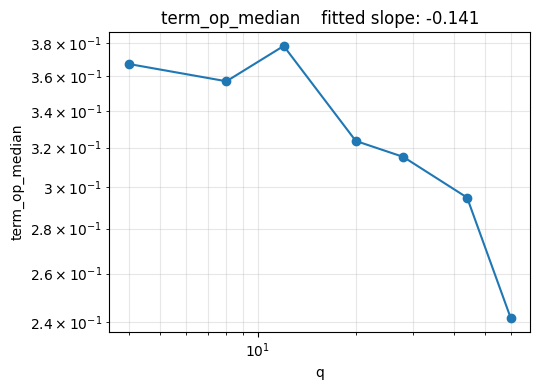

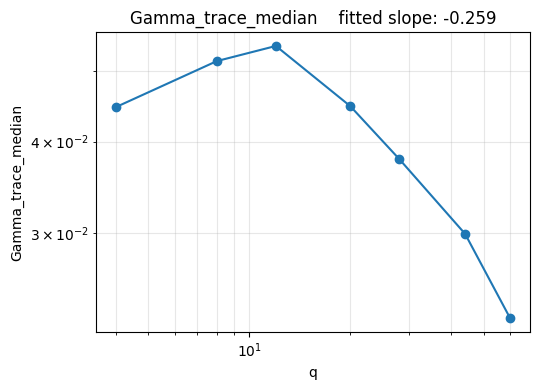

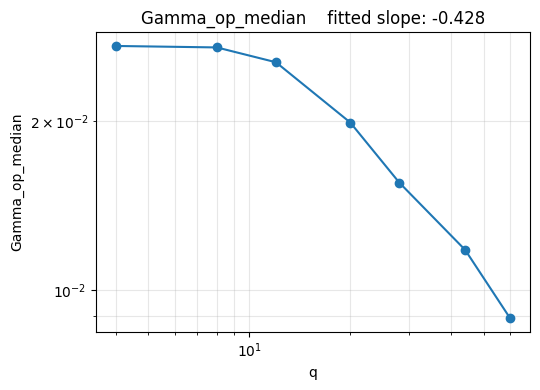

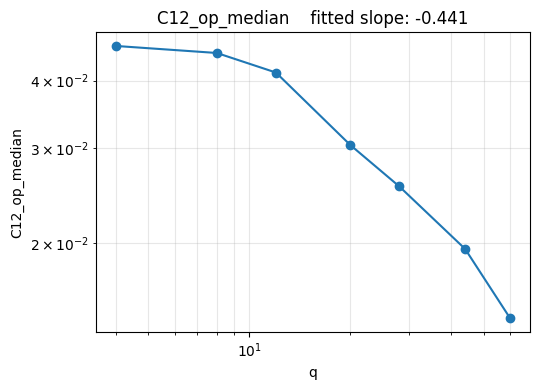

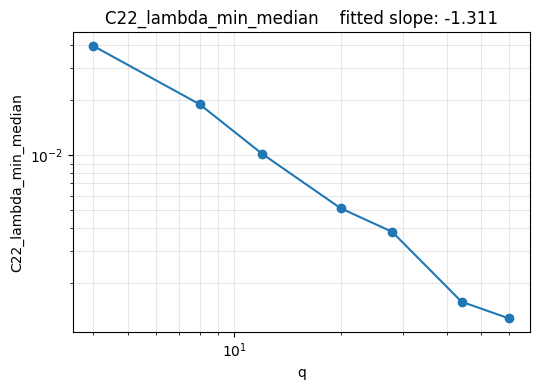

In [ ]:

# ---------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------
#
# 1. Scaling with nout, with ntr proportional to nout:

raw, summary, slopes = run_scaling_experiment(
    d=2,
    nout_values=(8, 12, 16, 24, 32, 48, 64),
    ntr_multiplier=100,
    trials=30,
    noise="gaussian",      # large-shot limit; fastest
    seed=7,
    rcond=1e-12,
)

display(summary)
display(slopes)
plot_scaling(summary, xcol="q")


nout=   32, ntr=   128, trials=30
nout=   32, ntr=   256, trials=30
nout=   32, ntr=   512, trials=30
nout=   32, ntr=  1024, trials=30
nout=   32, ntr=  2048, trials=30
nout=   32, ntr=  4096, trials=30


/tmp/ipykernel_3491540/177977974.py:94: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(np.log(x[mask]), np.log(y[mask]), deg=1)
/tmp/ipykernel_3491540/177977974.py:94: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(np.log(x[mask]), np.log(y[mask]), deg=1)
/tmp/ipykernel_3491540/177977974.py:94: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(np.log(x[mask]), np.log(y[mask]), deg=1)
/tmp/ipykernel_3491540/177977974.py:94: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(np.log(x[mask]), np.log(y[mask]), deg=1)
/tmp/ipykernel_3491540/177977974.py:94: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(np.log(x[mask]), np.log(y[mask]), deg=1)


,d,r,nout,ntr,q,p_kernel,Nshots,noise,trials,term_op_mean,...,term_fro_median,C12_op_median,Xi21_op_median,Gamma_op_median,Gamma_trace_median,C22_lambda_min_median,C22_cond_median,C22_kept_rank_min,P_numerical_rank_min,q_over_p
0,2,4,32,128,28,124,10000,gaussian,30,0.323249,...,0.404252,0.024791,1.136514,0.014419,0.035402,0.003906,18.509395,28,4,0.225806
1,2,4,32,256,28,252,10000,gaussian,30,0.280112,...,0.336990,0.023620,1.081721,0.013315,0.032607,0.003815,18.308548,28,4,0.111111
2,2,4,32,512,28,508,10000,gaussian,30,0.302547,...,0.363085,0.024918,1.146141,0.015586,0.032642,0.003510,19.881164,28,4,0.055118
3,2,4,32,1024,28,1020,10000,gaussian,30,0.284083,...,0.337390,0.023457,1.125003,0.013839,0.032788,0.003578,18.086878,28,4,0.027451
4,2,4,32,2048,28,2044,10000,gaussian,30,0.331646,...,0.391012,0.023617,1.142062,0.014204,0.035478,0.003575,19.286162,28,4,0.013699
5,2,4,32,4096,28,4092,10000,gaussian,30,0.320779,...,0.355831,0.026554,1.100760,0.017417,0.039810,0.003715,19.530025,28,4,0.006843


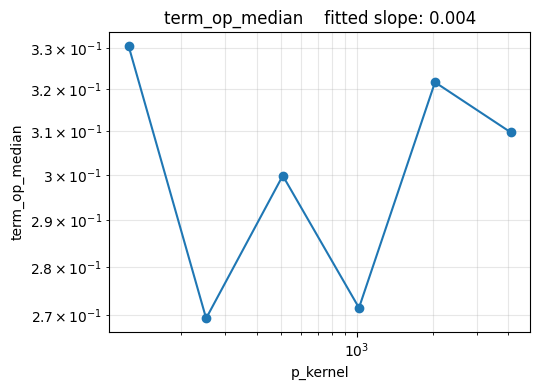

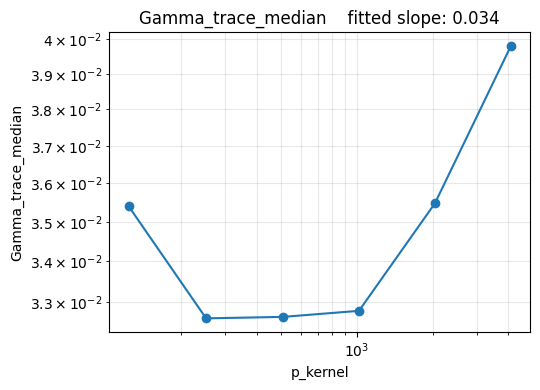

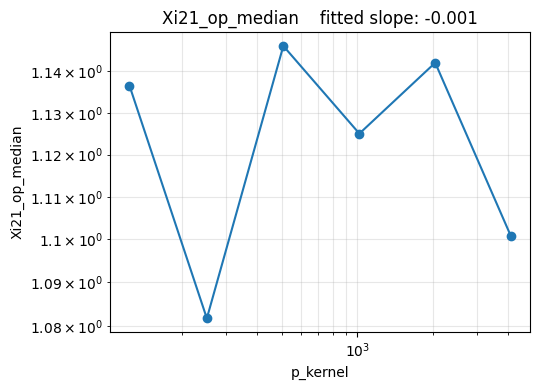

In [3]:

# 2. Fixed nout, increasing ntr:

raw_ntr, summary_ntr, slopes_ntr = run_ntr_sweep(
    d=2,
    nout=32,
    ntr_values=(128, 256, 512, 1024, 2048, 4096),
    trials=30,
    noise="gaussian",
    seed=8,
)

display(summary_ntr)
plot_scaling(
    summary_ntr,
    xcol="p_kernel",
    ycols=("term_op_median", "Gamma_trace_median", "Xi21_op_median"),
)


# 3. Exact multinomial noise instead of Gaussian noise:
#
# raw_m, summary_m, slopes_m = run_scaling_experiment(
#     d=2,
#     nout_values=(8, 12, 16, 24, 32),
#     ntr_multiplier=100,
#     trials=10,
#     Nshots=5000,
#     noise="multinomial",
#     seed=9,
# )
#
# display(summary_m)